## Librairie à utiliser

In [3]:
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(GGally)
library(dplyr)



## Récupération du jeu de données

In [4]:
data<-read.csv("healthcare_synthetic_data.csv")
summary(data)
head(data)

  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


Les variables quantitatives sont : Age, Height_cm, Weight_kg, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_LDL, Cholesterol_HDL, Fasting_Blood_Sugar.


Les variables qualitatives sont : Patient_ID, Gender, Smoking_status, Alcohol_Consumption, Physical_Activity_Level, Heart_Disease_Risk, Family_History,, Stress_Level, Sleep_Hours.

Nous avons décidé de supprimer la variable Patient_ID car il est différent pour tous les patients. Par conséquent elle ne donne pas d'information supplémentaire sur le patient.
Nous avons égalemement transformé en variables qualitatives qui n'avait pas été comprise par R.

In [5]:
#suppression de la variable Patient_ID.
data=data[,c(2:19)]

data[, "Gender"] <- as.factor(data[, "Gender"])
data$Gender <- factor(data$Gender, 
                      levels = c(0, 1), 
                      labels = c("Female", "Male"))
data[,"Smoking_Status"]= as.factor(data[,"Smoking_Status"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[,"Stress_Level"]= as.factor(data[,"Stress_Level"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[,"Sleep_Hours"]= as.factor(data[,"Sleep_Hours"])
summary(data)

      Age           Gender       Height_cm       Weight_kg           BMI       
 Min.   :25.00   Female:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   Male  :7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00                 Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54                 Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00                 3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00                 Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                               
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd

# Analyse exploratoire des données

## Statistiques unidimentionnelles

### Variables quantitatives

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


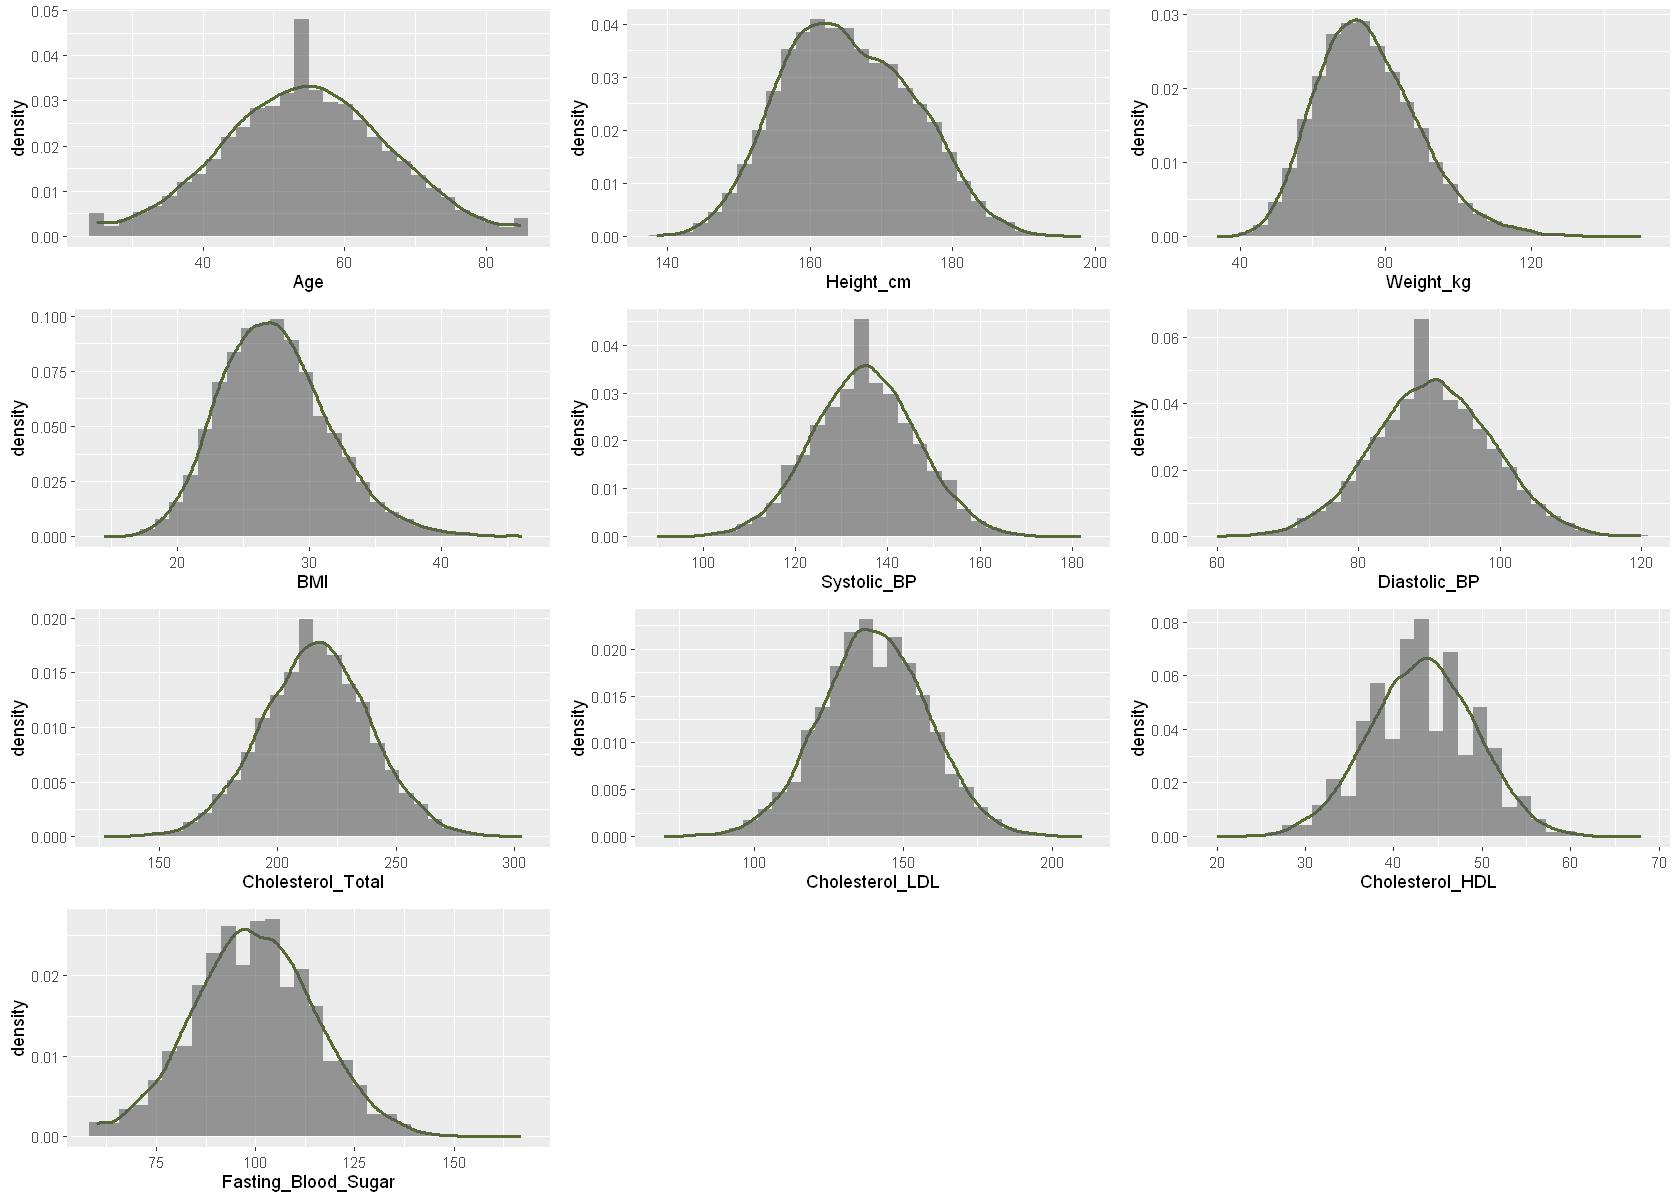

In [7]:
# Etude densité des variables quantitatives
g1=ggplot(data,aes(x=Age)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g2=ggplot(data,aes(x=Height_cm)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g3=ggplot(data,aes(x=Weight_kg)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g4=ggplot(data,aes(x=BMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g5=ggplot(data,aes(x=Systolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g6=ggplot(data,aes(x=Diastolic_BP)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g7=ggplot(data,aes(x=Cholesterol_Total)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g8=ggplot(data,aes(x=Cholesterol_LDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g9=ggplot(data,aes(x=Cholesterol_HDL)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
g10=ggplot(data,aes(x=Fasting_Blood_Sugar)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))

options(repr.plot.width = 14, repr.plot.height = 10)
grid.arrange(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,ncol=3)
#rm(g1,g2,g3,g4,g5,g6,g7,g8,g9,g10,)

Fasting_Blood_Sugar et Height_cm ne semblent pas symétriques, on applique donc une transformation pour les rendre plus symétriques et donc plus "gaussiennes". Ces transformations sont paraissent donc pertinentes, elle permet d'étudier des courbes gaussiennes ou presque.

je vois pas forcément de modification je sais pas si c'est judicieux, Par contre pour BMI et Weigth peu_etre c'est meiux de le faire.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


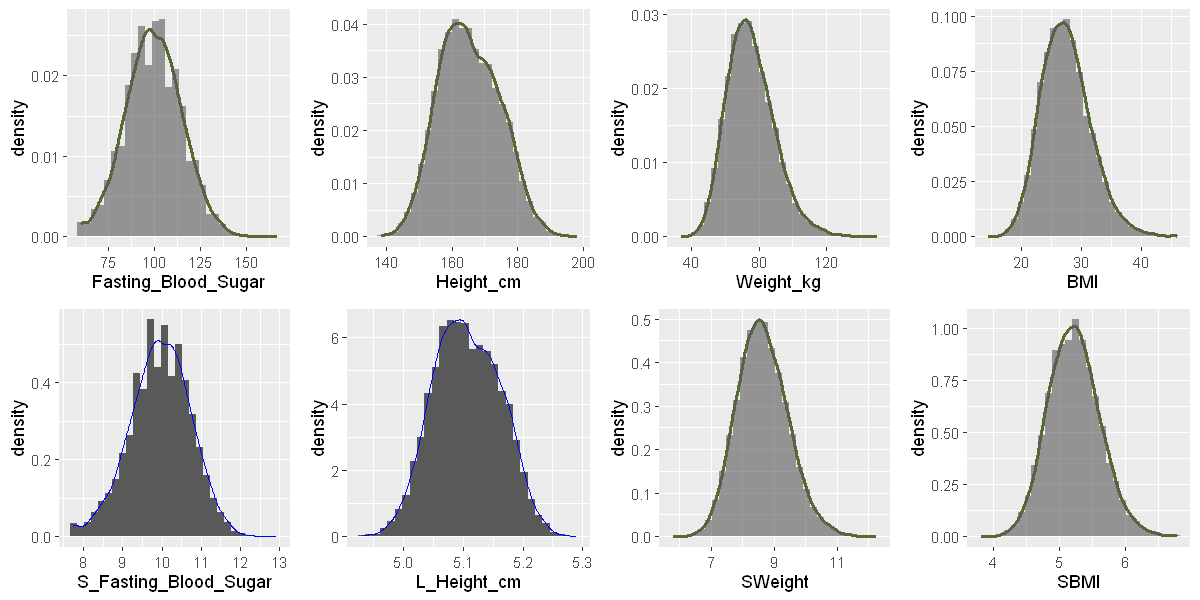

In [10]:
#Tranformation (racine carrée) de Weight_kg et BMI pour centrer les densitées
options(repr.plot.width = 10, repr.plot.height = 5)
data[,"SBMI"]=sqrt(data[,"BMI"])
data[,"SWeight"]=sqrt(data[,"Weight_kg"])
data[, "S_Fasting_Blood_Sugar"] <- sqrt(data[, "Fasting_Blood_Sugar"])
data[, "L_Height_cm"] <- log(data[, "Height_cm"])

sg1<-ggplot(data,aes(x=S_Fasting_Blood_Sugar))+geom_histogram(aes(y=..density..))+geom_density(alpha=.2, col="blue") 
sg2<-ggplot(data,aes(x=L_Height_cm))+
  geom_histogram(aes(y=..density..))+
  geom_density(alpha=.2, col="blue") 
sg4=ggplot(data,aes(x=SBMI)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
sg3=ggplot(data,aes(x=SWeight)) + geom_density(linewidth=1,col="darkolivegreen") + geom_histogram(alpha=0.6,aes(y=after_stat(density)))
grid.arrange(g10,g2,g3,g4,sg1,sg2,sg3,sg4,ncol=4)

### Variable qualitatives (à faire)

# Analyse bidimensionnelle

**1.Corrélation entre variables quantitatives**

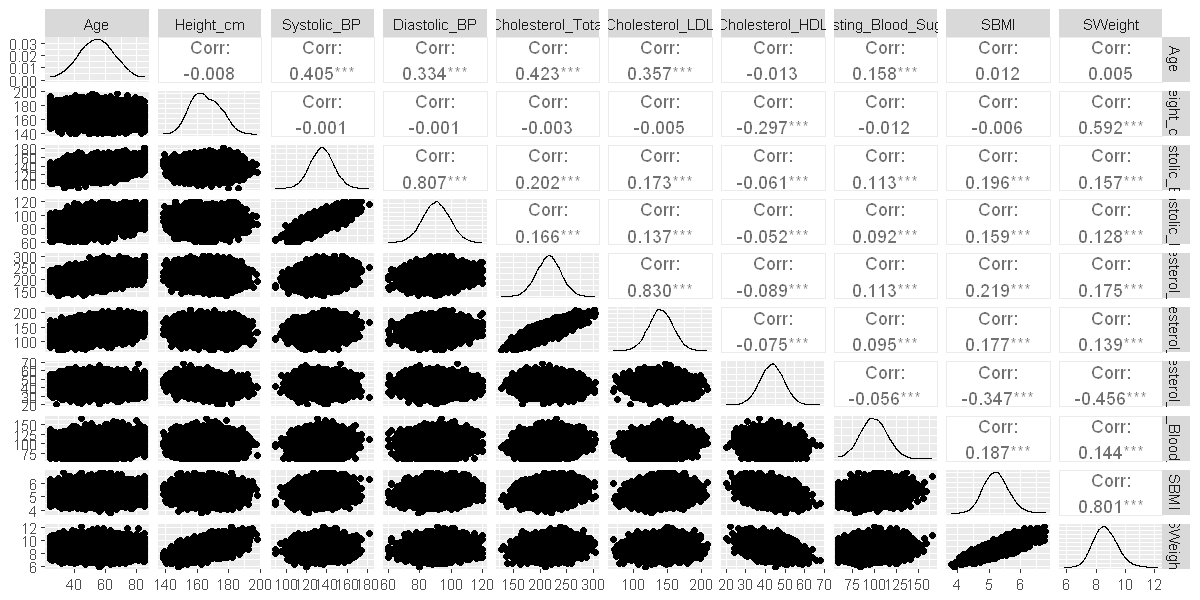

In [11]:
data_quanti=data[,c(1,3,6:11,19:20)]
ggpairs(data_quanti)


On remarque 3 paires de variables très corrélées (avec des valeurs de correlation autour de 0.8): le **poids du patient** avec le **BMI**, la **pression artérielle systolique** avec la **pression artérielle diastolique** et le taux de **cholesterol total** avec le taux de **cholesterol LDL**.

Aussi **Height** avec **SWeight**

Cela semble logique quand on s'intérresse à la description de ses variables (elles mesures les mêmes trucs) cependant il est surprenant que le taux de cholesterol total soit très corrélé avec le taux de cholesterol LDL ("mauvais") mais presque pas avec le HDL ("bon") (correlation de 0.830 contre -0.089). Les deux types de cholesterol ne semblent pas non plus corrélées entre eux.



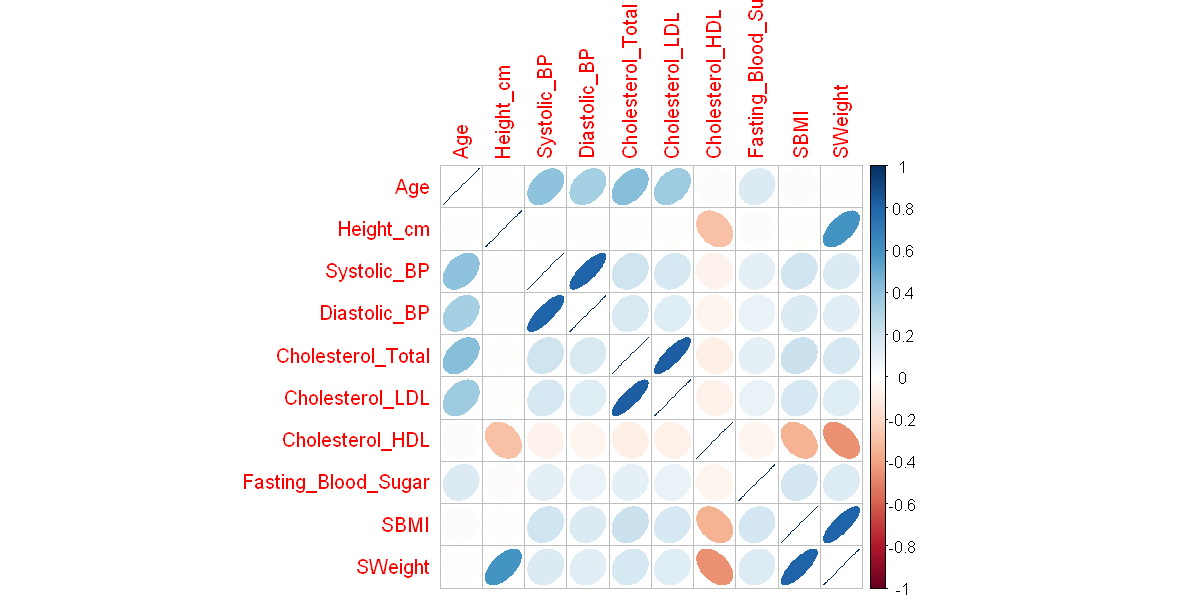

In [12]:
library(corrplot)
#corrplot(cor(data[, c(1, 3:11)]),method="ellipse")
corrplot(cor(data_quanti),method="ellipse")

**2.Corrélations entre variables qualitatives et quantitatives**

On s'intérresse dans cette partie aux effets de differentes variables sur la variable Heart_Disease_Risk

### Influence du genre en sur les risques de maladies cardio-vasculaires

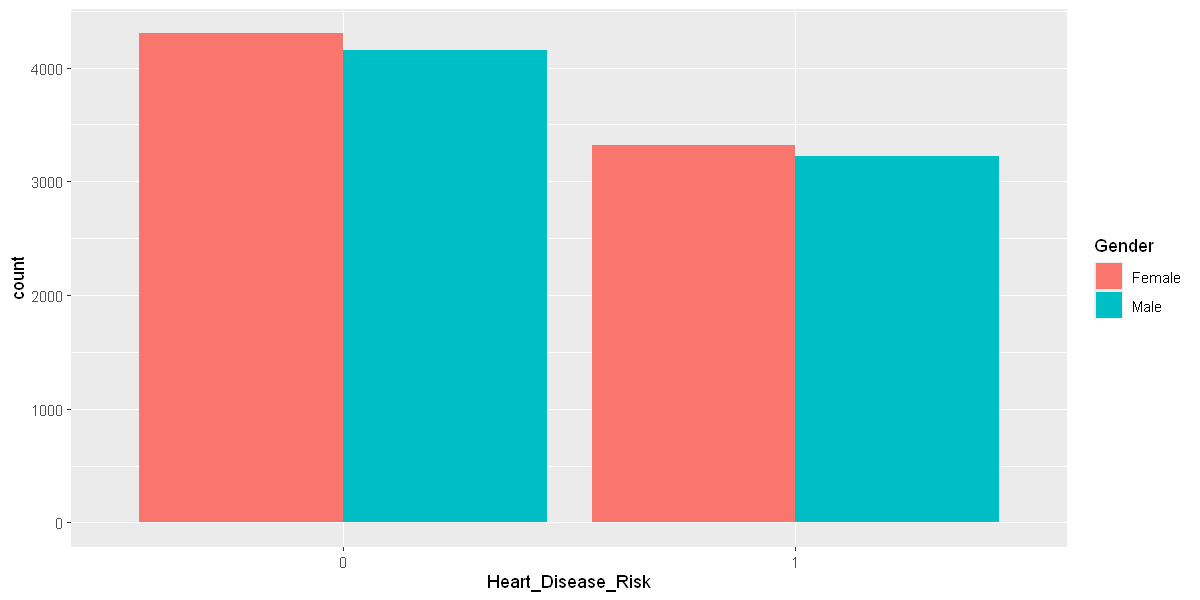

In [13]:
ggplot(data,
       aes(x=Heart_Disease_Risk,
           fill=Gender))+
       geom_bar(position = "dodge")

On voit qu'il n'y a pas de difference de genre sur les risque cardio vasculaire.

### Etude de l'impact des différents taux de cholesterol sur le risque cardiaque en fonction du genre

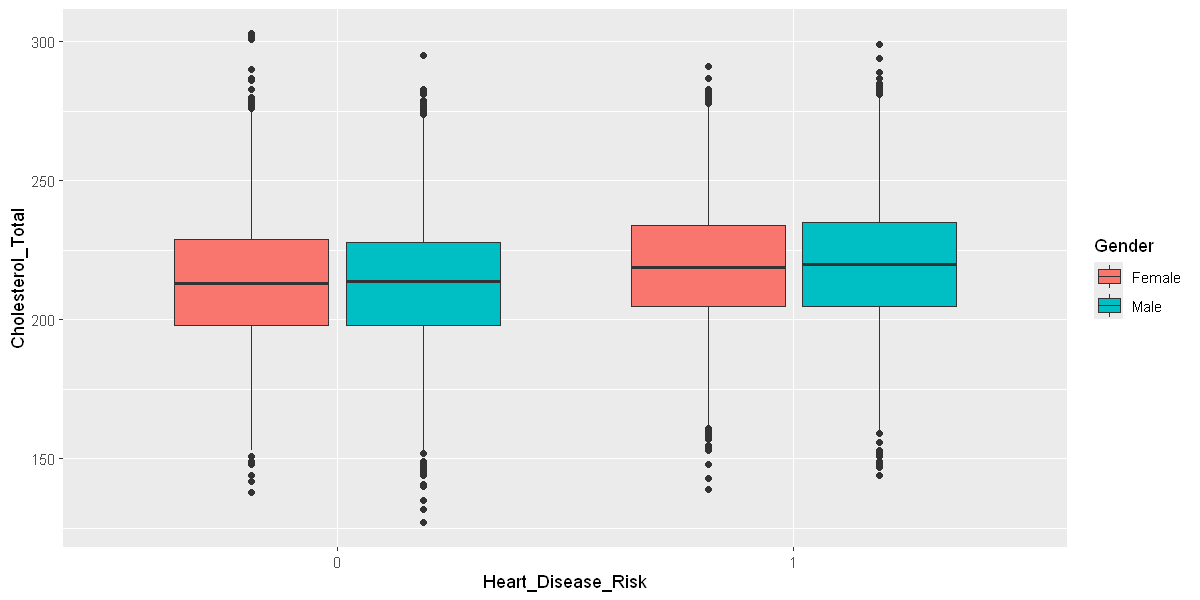

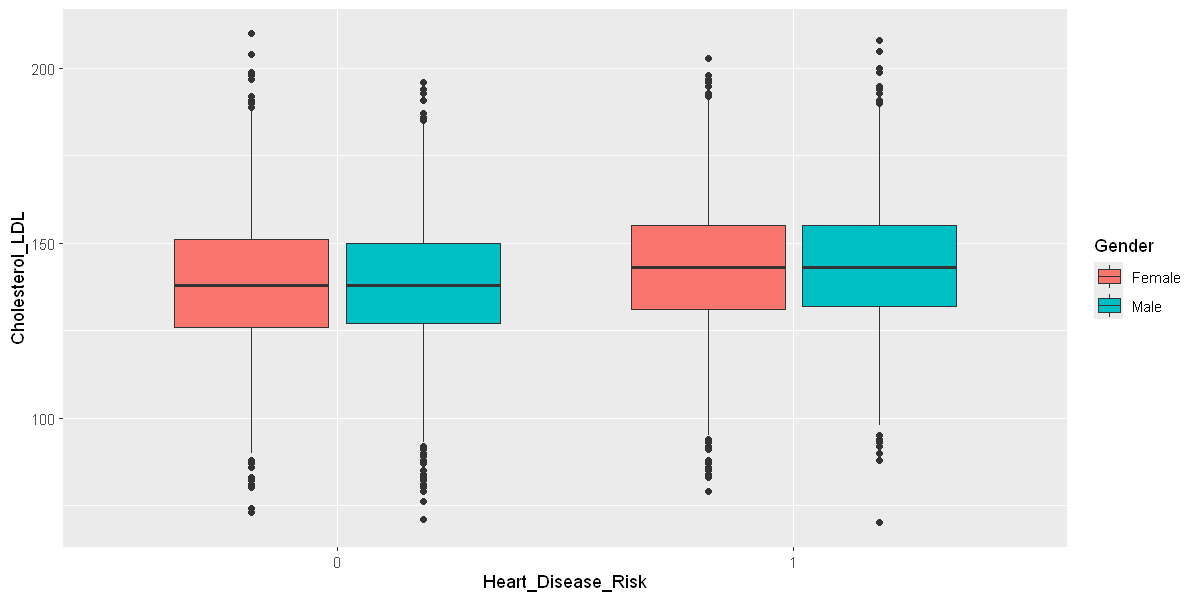

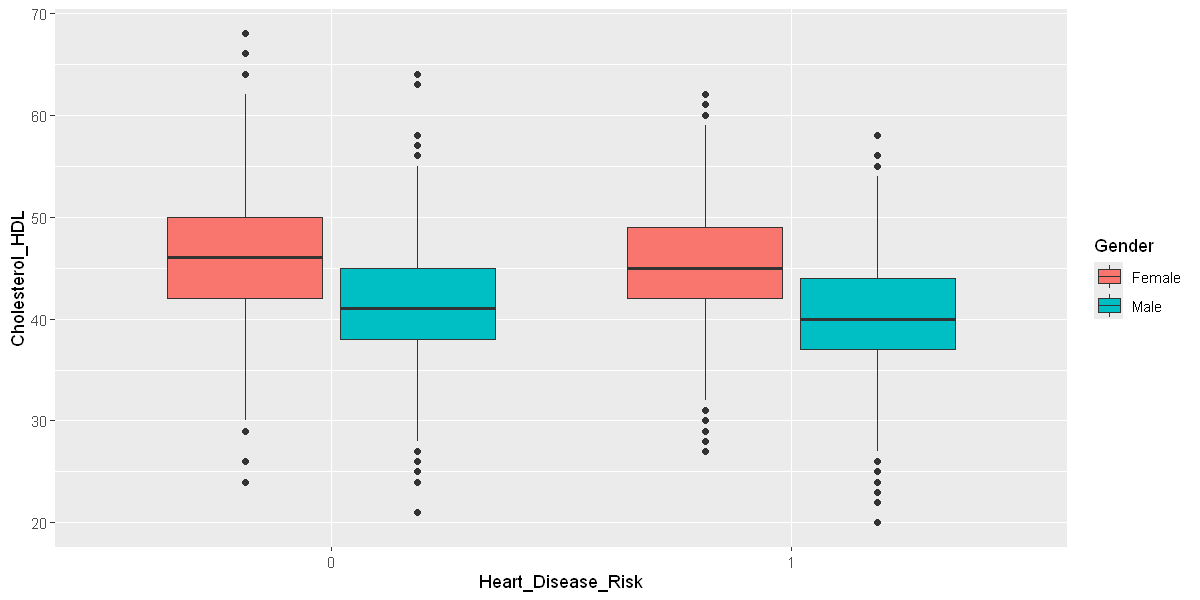

In [14]:

ggplot(data, 
       aes(x = Heart_Disease_Risk, 
           y= Cholesterol_Total,
           fill = Gender)) +
  geom_boxplot()
ggplot(data, 
       aes(x = Heart_Disease_Risk, 
           y= Cholesterol_LDL,
           fill = Gender)) +
  geom_boxplot()
ggplot(data, 
       aes(x = Heart_Disease_Risk, 
           y= Cholesterol_HDL,
           fill = Gender)) +
  geom_boxplot()

#On remarque effet inverse du bon cholesterol
#effet du genre sur le taux de bon cholesterol

Effet du genre sur le taux de bon cholesterol

**3.Corrélation qualitatif-qualitatif**

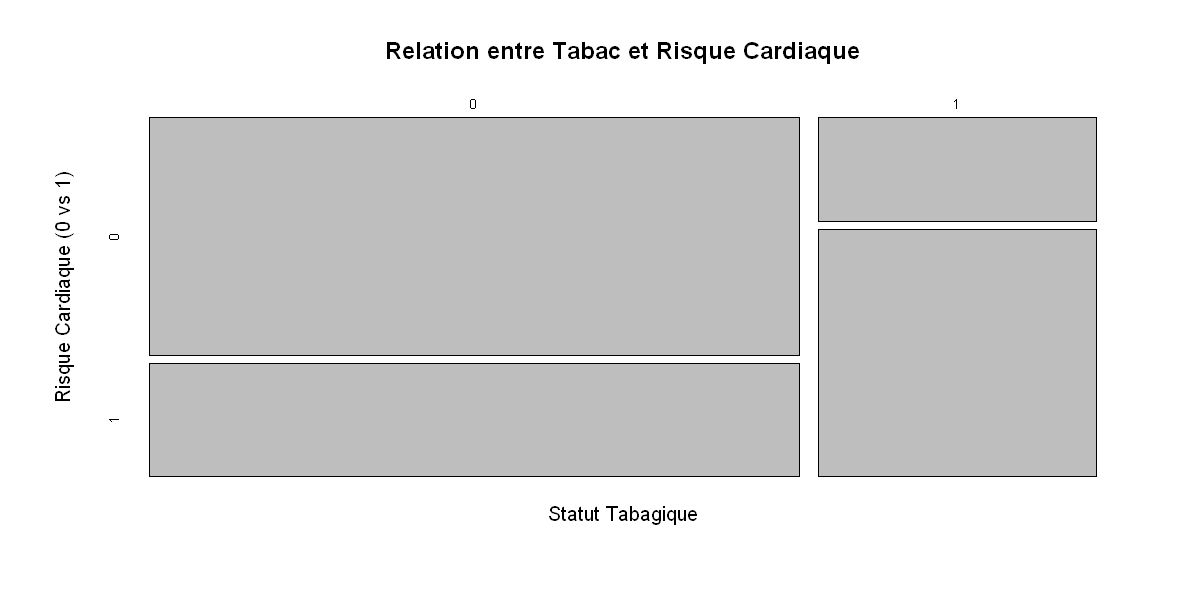

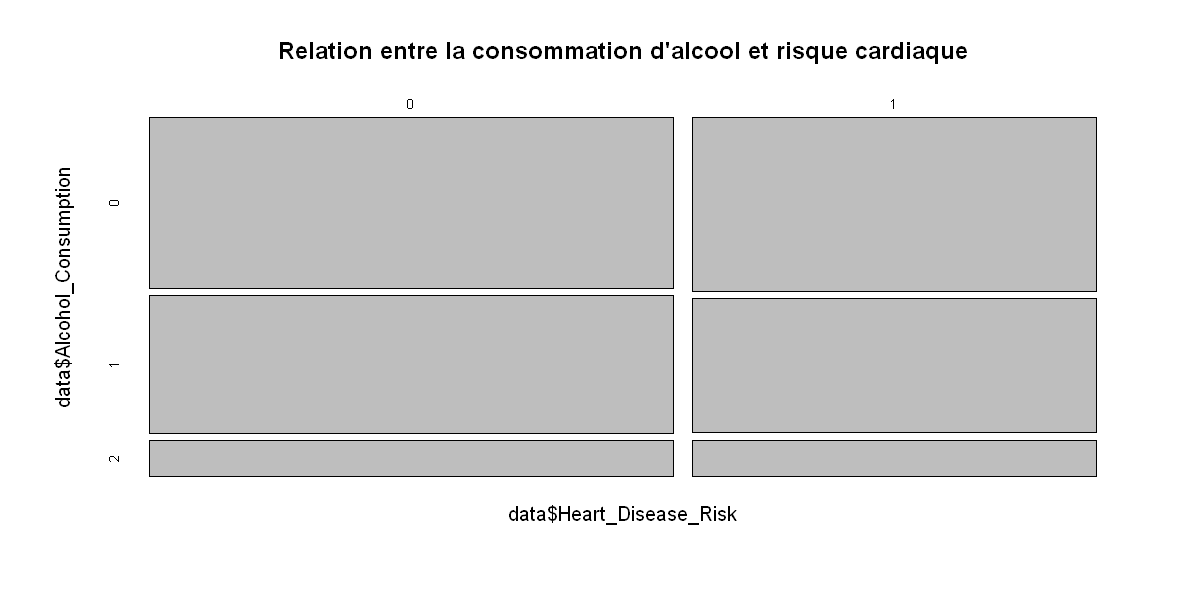

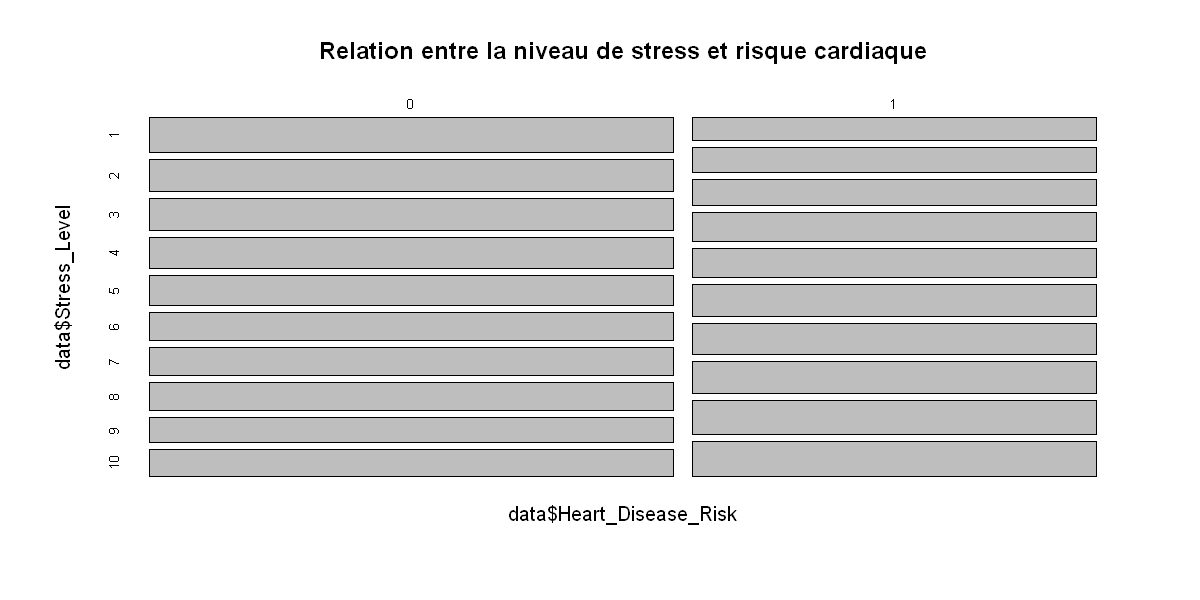

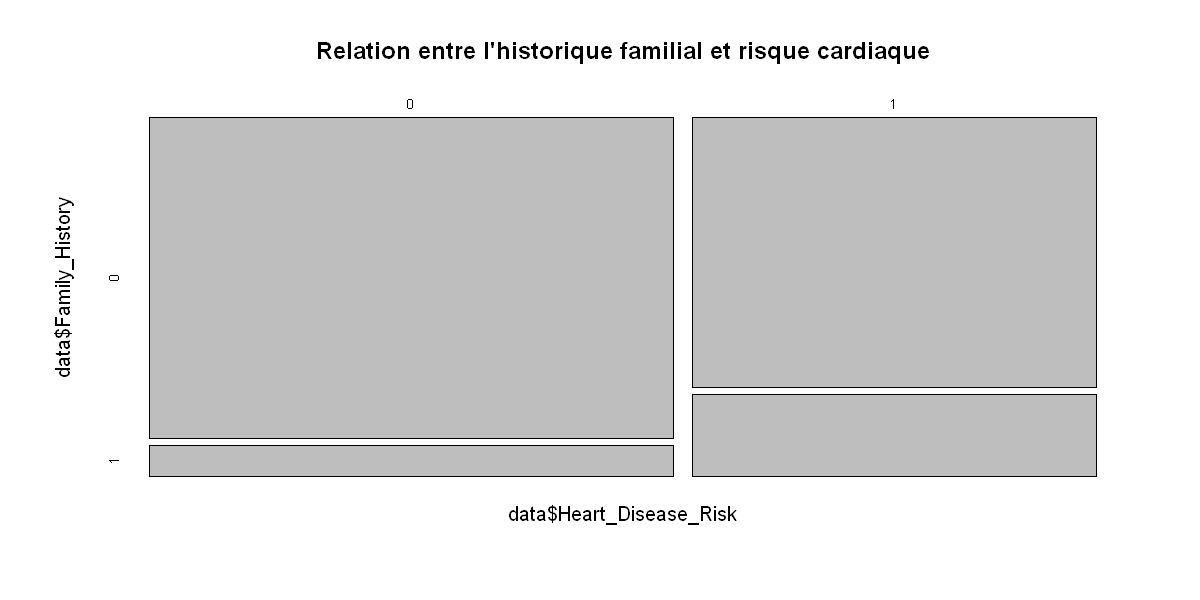

In [15]:
#Rendre jolie les labels ? 
mosaicplot(data$Smoking_Status~data$Heart_Disease_Risk,main = "Relation entre Tabac et Risque Cardiaque",xlab = "Statut Tabagique",ylab = "Risque Cardiaque (0 vs 1)")
mosaicplot(data$Heart_Disease_Risk~ data$Alcohol_Consumption,main="Relation entre la consommation d'alcool et risque cardiaque")
mosaicplot(data$Heart_Disease_Risk~ data$Stress_Level,main="Relation entre la niveau de stress et risque cardiaque")
mosaicplot(data$Heart_Disease_Risk~ data$Family_History,main="Relation entre l'historique familial et risque cardiaque")

# ACP

Puisque nous avons des variables avec des valeurs très différentes, il est nécessaire de centrer et réduire les données(scale.unit=TRUE).

In [19]:
res_pca=PCA(data_quanti, scale.unit = TRUE, graph = TRUE)
res_pca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,2.920348115,29.20348115,29.20348
comp 2,2.038507589,20.38507589,49.58856
comp 3,1.480201212,14.80201212,64.39057
comp 4,1.056203873,10.56203873,74.95261
comp 5,0.907242109,9.07242109,84.02503
comp 6,0.686557007,6.86557007,90.89060
comp 7,0.556584708,5.56584708,96.45645
comp 8,0.188838699,1.88838699,98.34483
comp 9,0.164501055,1.64501055,99.98984
comp 10,0.001015633,0.01015633,100.00000


On va garder les 5 premières composantes principales car à elles, elles expliquent plus de 80% de la variance.

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


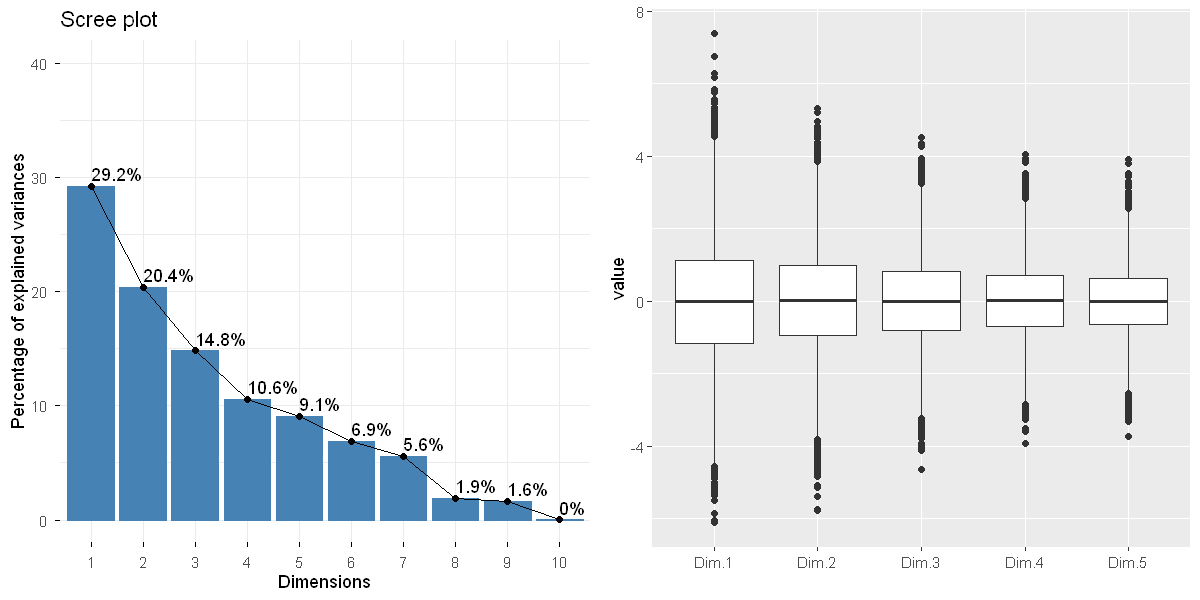

In [24]:
g1<-fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 40))
g2<-ggplot(melt(res_pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)

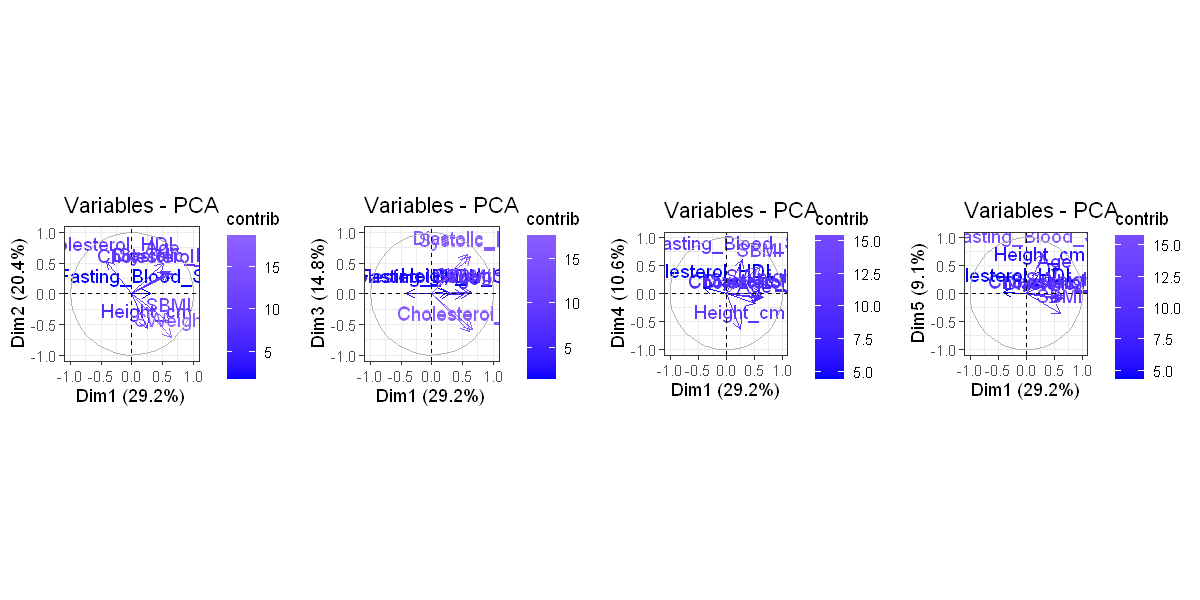

In [40]:


v1=fviz_pca_var(res_pca,axes=c(1,2), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v2=fviz_pca_var(res_pca,axes=c(1,3), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v3=fviz_pca_var(res_pca,axes=c(1,4), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v4=fviz_pca_var(res_pca,axes=c(1,5), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()



grid.arrange(v1,v2,v3,v4,ncol=4)

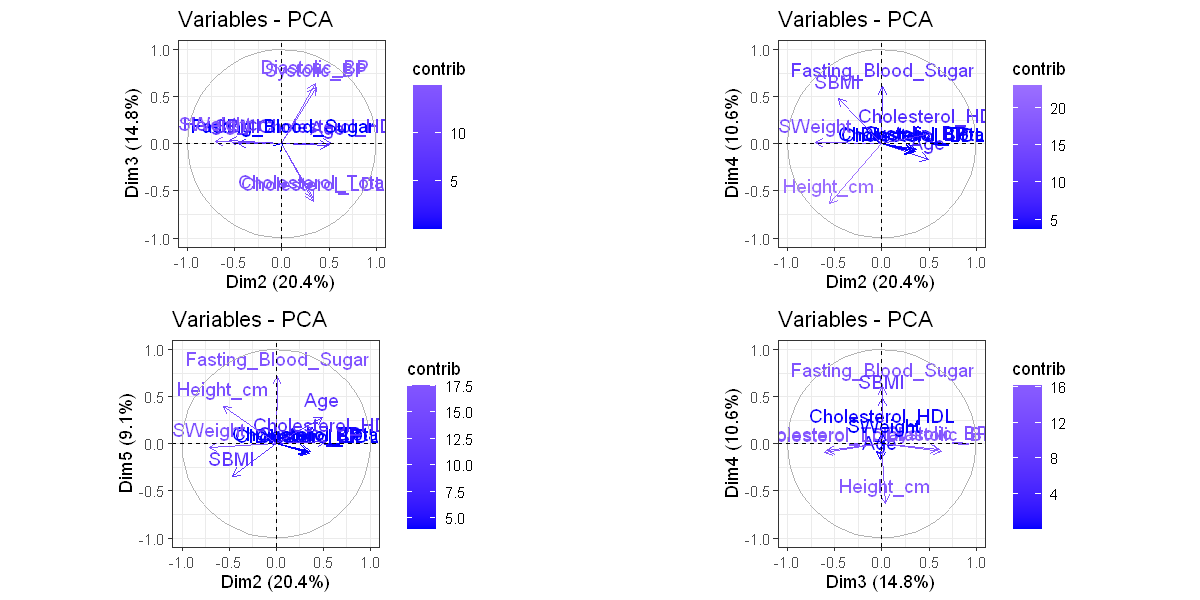

In [38]:
v5=fviz_pca_var(res_pca,axes=c(2,3), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v6=fviz_pca_var(res_pca,axes=c(2,4), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v7=fviz_pca_var(res_pca,axes=c(2,5), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v8=fviz_pca_var(res_pca,axes=c(3,4), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()

grid.arrange(v5,v6,v7,v8,ncol=2)

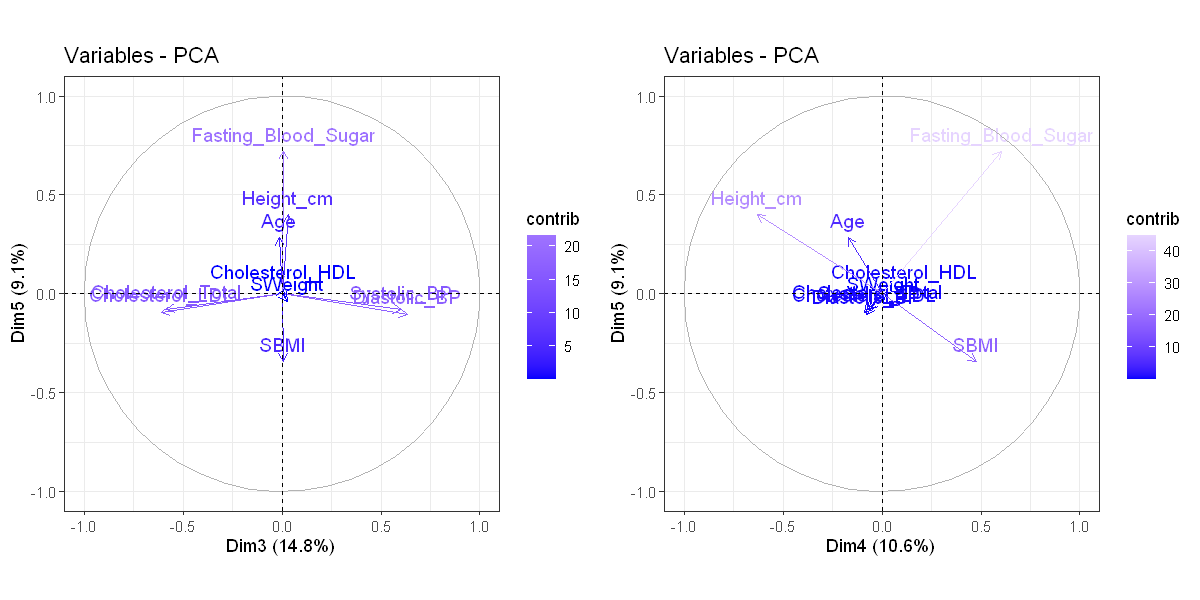

In [39]:
v9=fviz_pca_var(res_pca,axes=c(3,5), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
v10=fviz_pca_var(res_pca,axes=c(4,5), col.var="contrib")+
scale_color_gradient2(low="blue", mid="white", 
                      high="red", midpoint=55)+theme_bw()
grid.arrange(v9,v10,ncol=2)

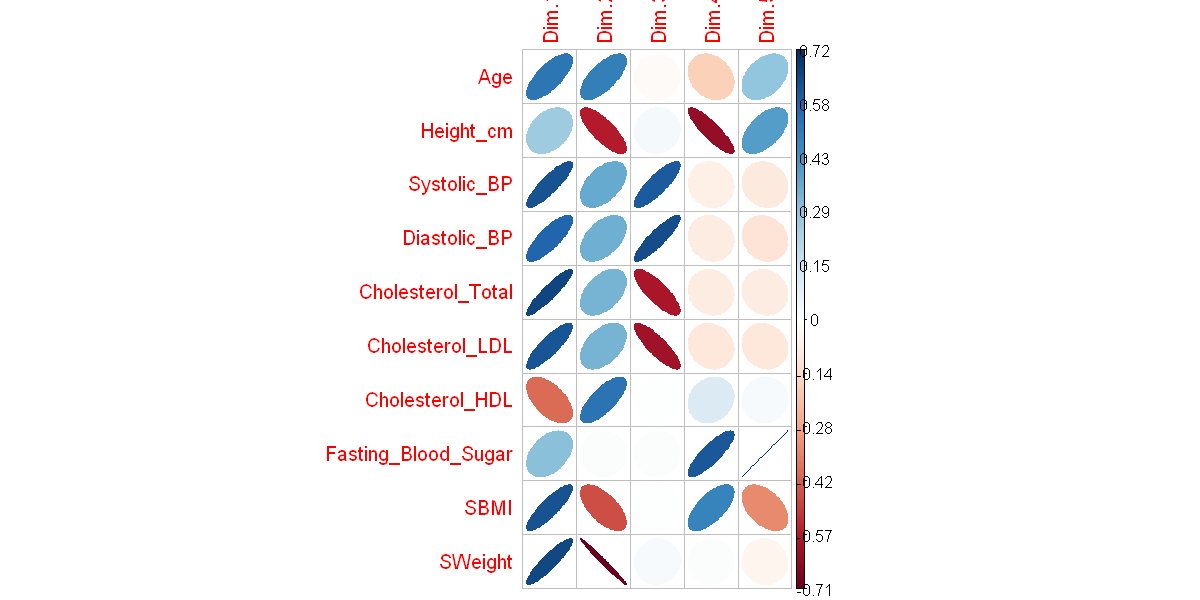

In [25]:
corrplot(res_pca$var$cor, is.corr=FALSE,method="ellipse")

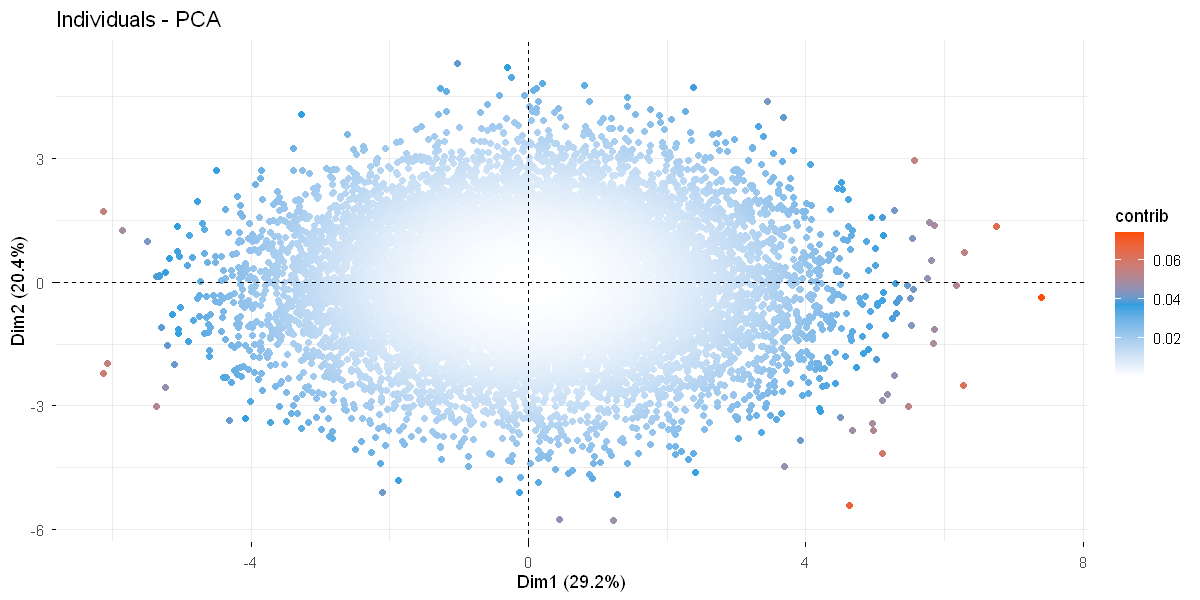

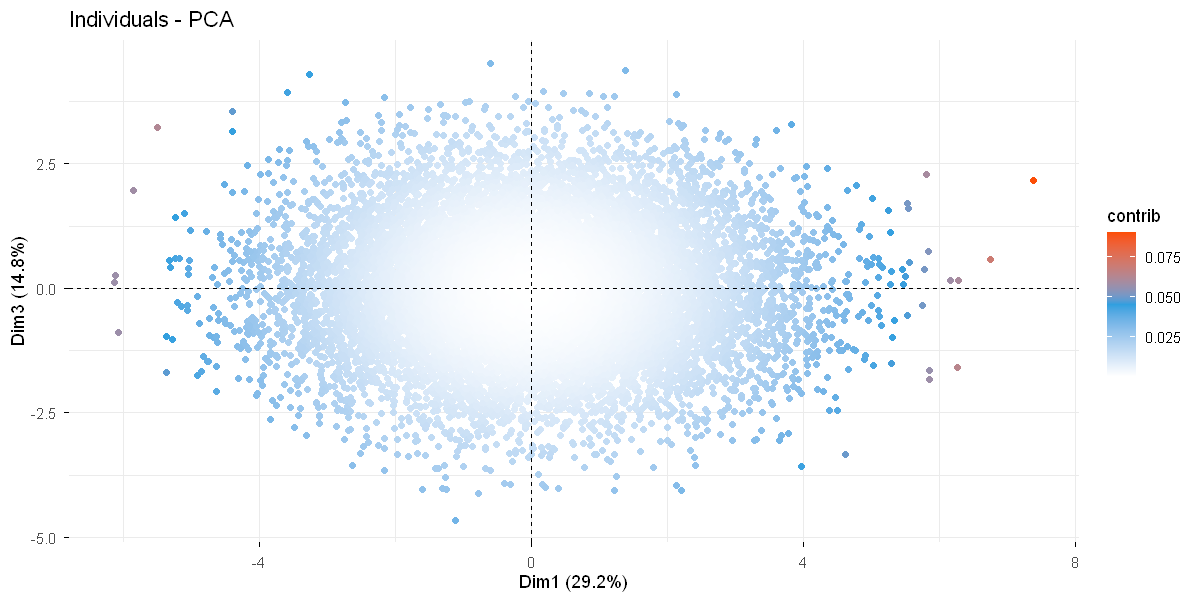

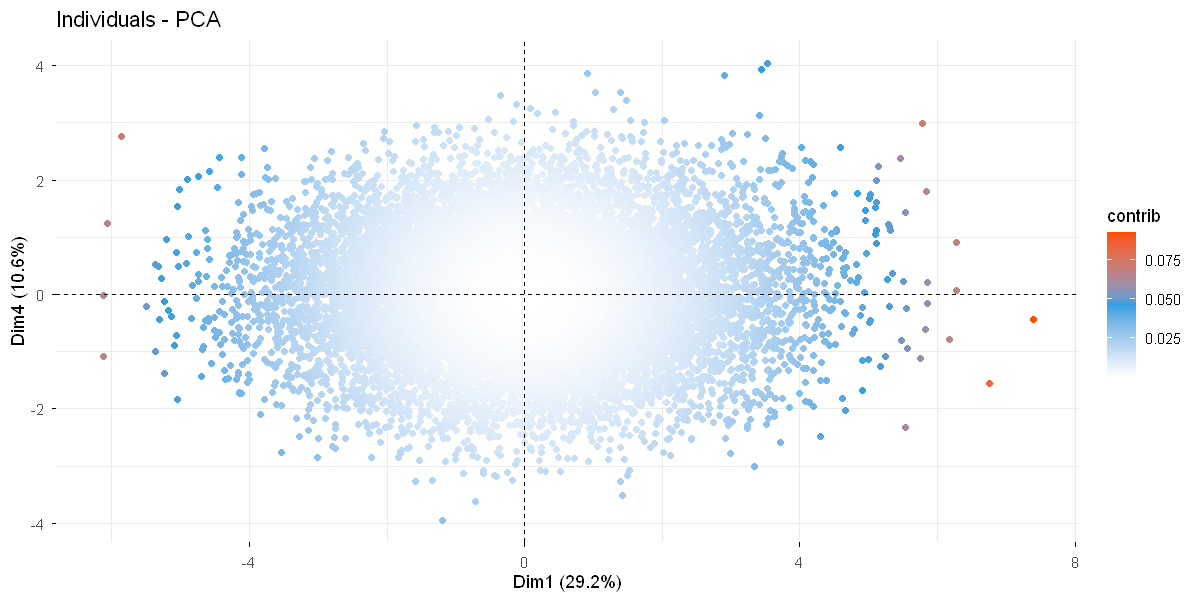

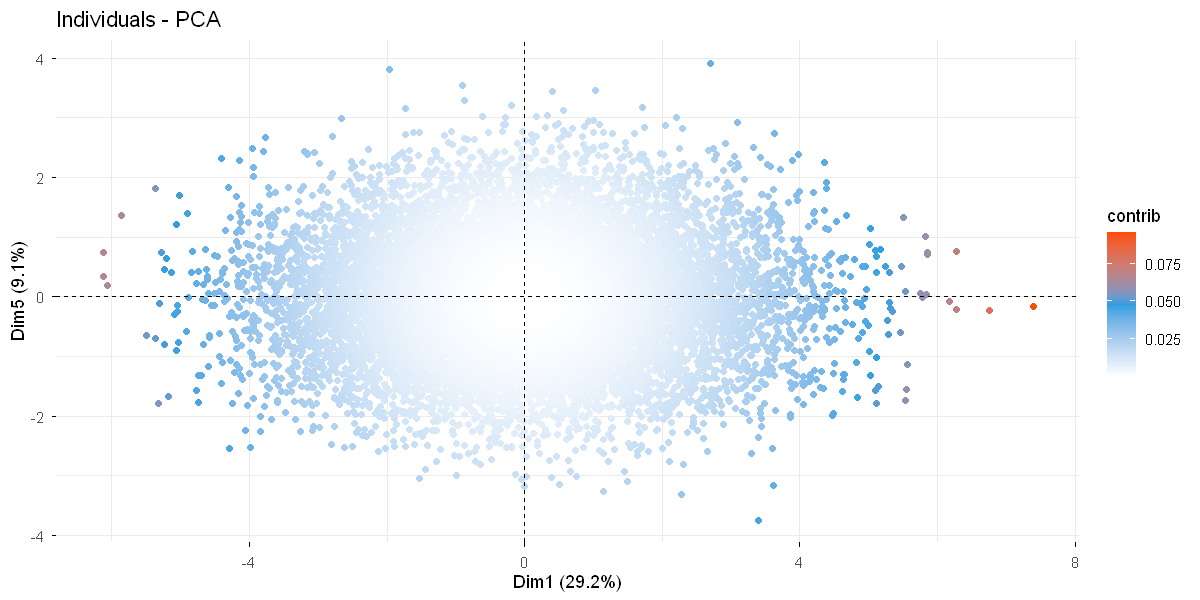

In [42]:
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))

fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,4))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,5))


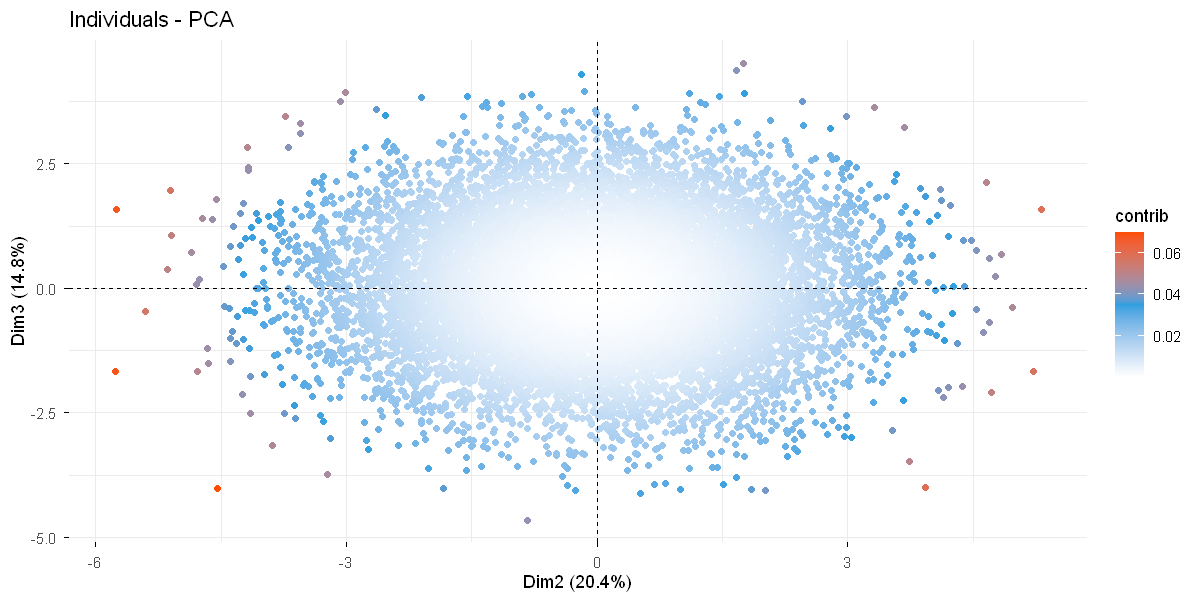

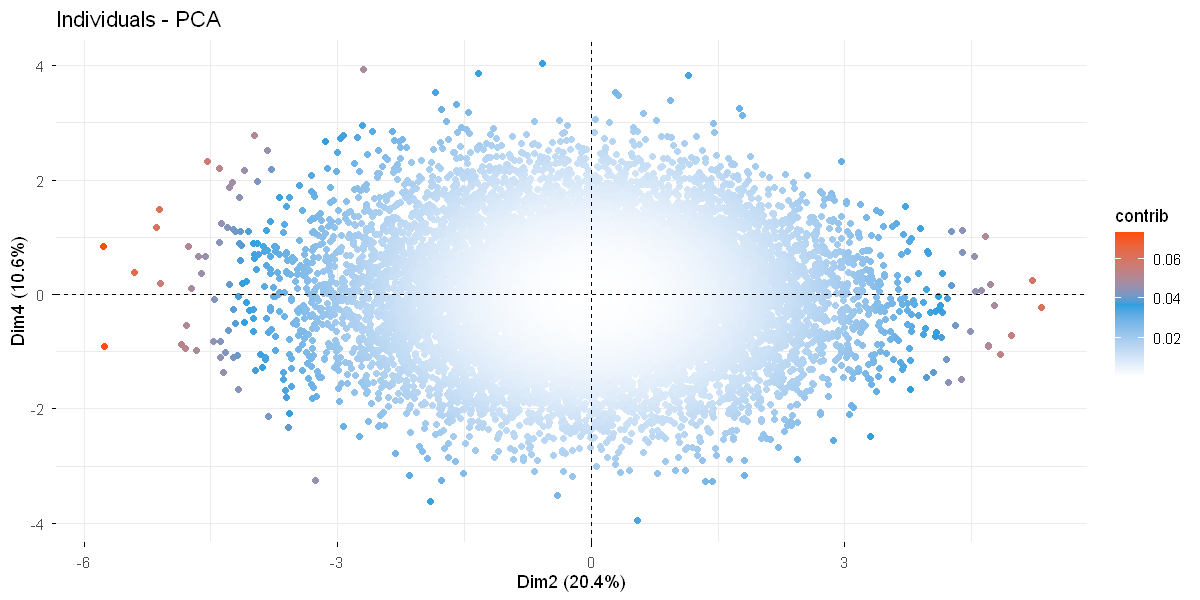

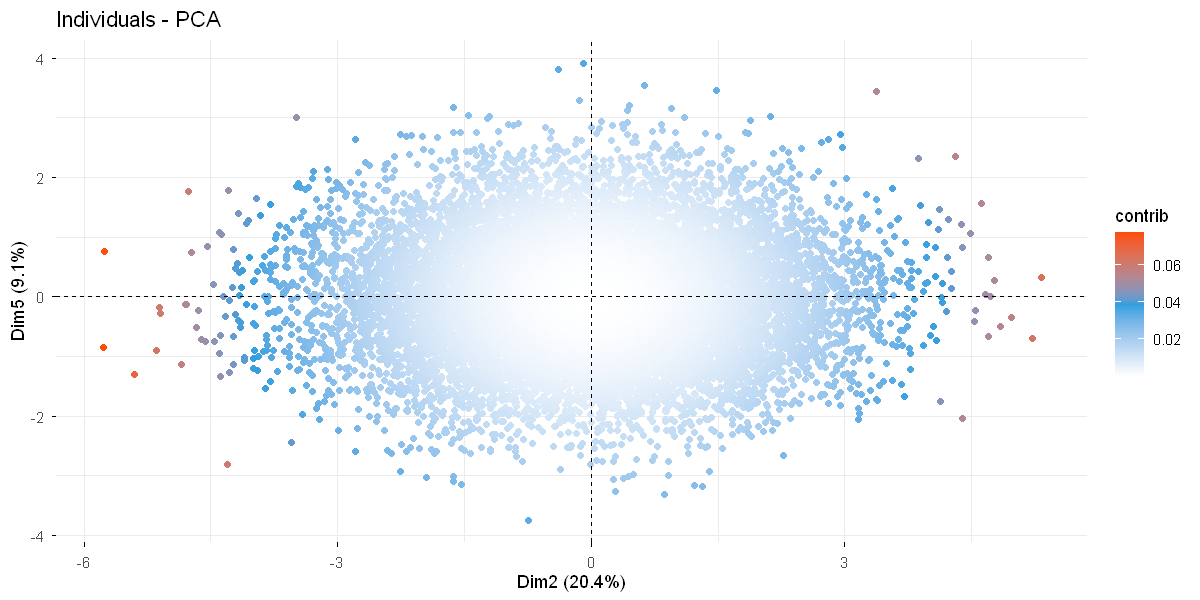

In [43]:
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(2,3))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(2,4))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(2,5))


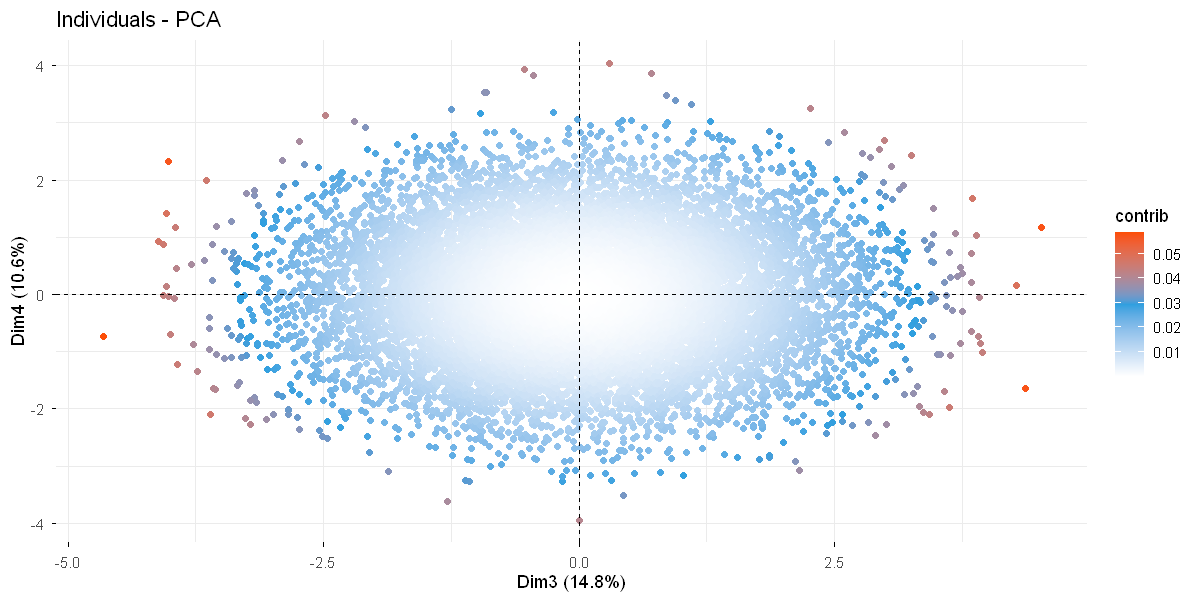

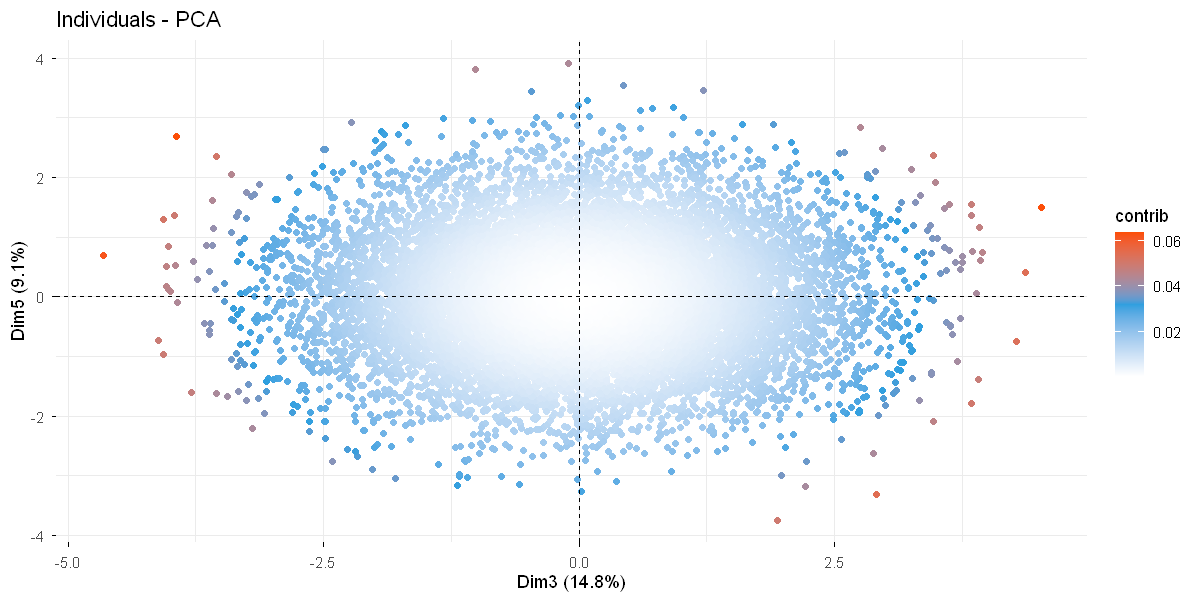

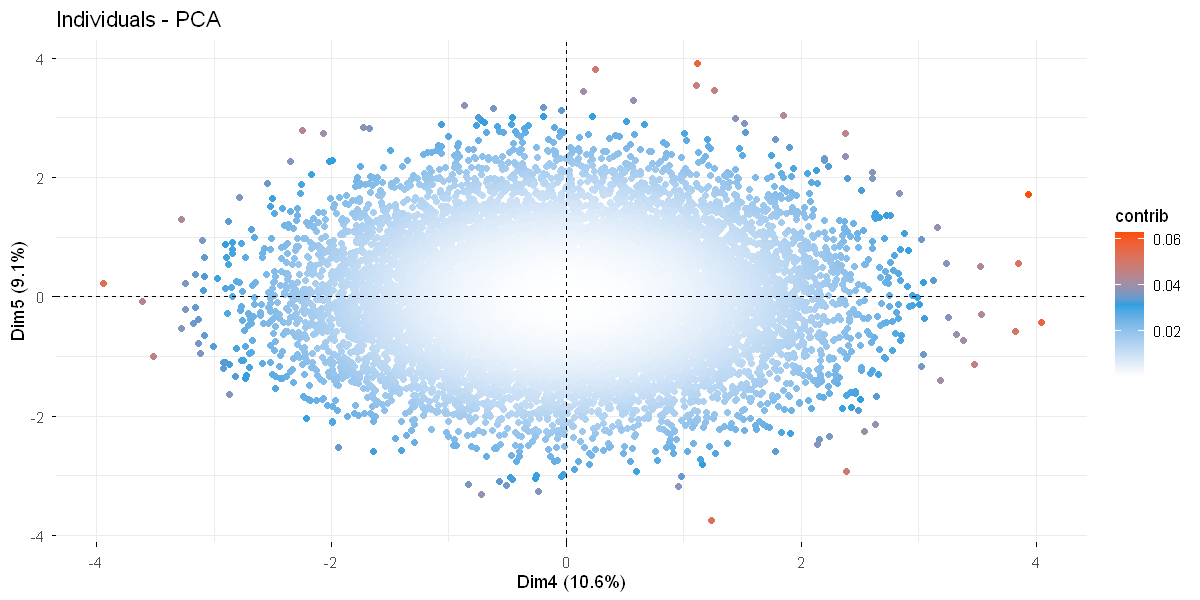

In [44]:
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(3,4))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(3,5))
fviz_pca_ind(res_pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(4,5))